In [ ]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Data Loading

In [7]:
train = pd.read_csv('C:/Users/Dell/Desktop/work/dsp/dsp_muhammadMahr_arshad/data/train.csv')
test = pd.read_csv('C:/Users/Dell/Desktop/work/dsp/dsp_muhammadMahr_arshad/data/test.csv')

train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Categorical feature selection

In [10]:
train['LandContour'].value_counts()
train['LandSlope'].value_counts()

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

# Continious feature selection

<Axes: >

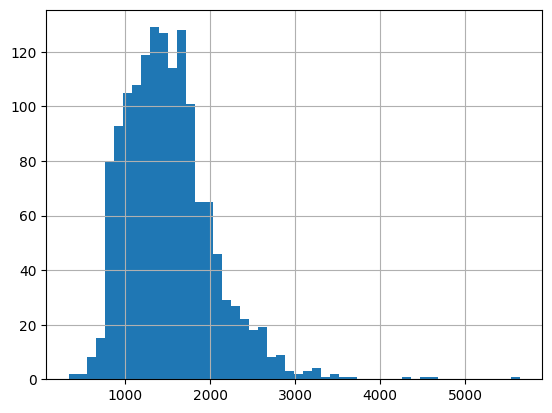

In [12]:
train['GrLivArea'].hist(bins=50)

<Axes: >

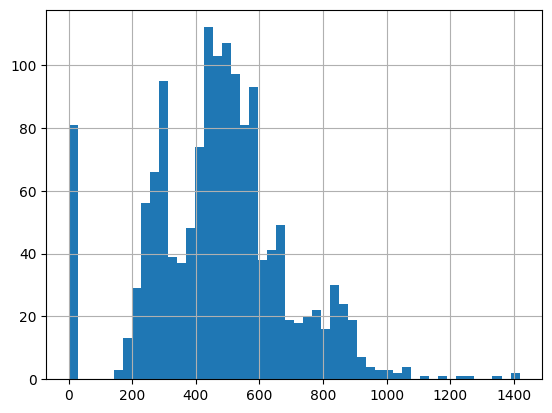

In [13]:
train['GarageArea'].hist(bins=50)

# Scaling of continous variables

In [15]:
scaler = StandardScaler()
train['GrLivArea'] = scaler.fit_transform(train[['GrLivArea']])
train['GarageArea'] = scaler.fit_transform(train[['GarageArea']])

# Encoding of categorical features

In [ ]:

le_contour = LabelEncoder()
train['LandContour'] = le_contour.fit_transform(train['LandContour'])

le_slope = LabelEncoder()
train['LandSlope'] = le_slope.fit_transform(train['LandSlope'])

# Spliting of dataset

In [ ]:
X = train[['GrLivArea', 'GarageArea', 'LandContour', 'LandSlope']]
y = train['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training and evaluation

In [ ]:
 
model = lgb.LGBMRegressor(
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=100
)
model.fit(X_train, y_train)
preds = model.predict(X_val)
from sklearn.metrics import mean_squared_error, root_mean_squared_error
mse = mean_squared_error(y_val, preds)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 515
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 4
[LightGBM] [Info] Start training from score 181441.541952
Mean Squared Error: 2029032718.8504229
Root Mean Squared Error: 45044.78570101564


<Axes: >

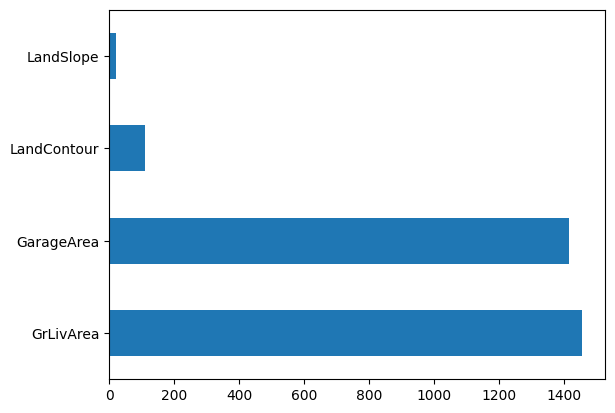

In [22]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
